This project aims to analyze how artificial intelligence is influencing student learning behavior, academic performance, and satisfaction. Specifically, it investigates the relationship between AI usage patterns and academic outcomes, while identifying key factors that contribute to improved or declining performance.

📊 Core Questions:
1. Does higher AI usage improve grades?
2. Which AI usage purpose is most common?
3. How does satisfaction vary with usage?
4. Does excessive usage reduce performance?
5. Which students benefit most from AI?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:/Users/kirii/Downloads/AI_Student_Life_india.csv')
df.head()

,Student_ID,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
0,1,15,Female,College,Hyderabad,Copilot,1.1,Learning,Slight Decline,Medium
1,2,21,Female,University,Chennai,Copilot,1.7,Coding,Slight Decline,High
2,3,22,Male,University,Bangalore,Gemini,1.5,Learning,Improved,Low
3,4,22,Male,College,Hyderabad,ChatGPT,3.8,Research,Improved,Low
4,5,22,Male,College,Hyderabad,Gemini,5.2,Coding,Slight Decline,Low


In [3]:
df.info

<bound method DataFrame.info of      Student_ID  Age  Gender Education_Level        City AI_Tool_Used  \
0             1   15  Female         College   Hyderabad      Copilot   
1             2   21  Female      University     Chennai      Copilot   
2             3   22    Male      University   Bangalore       Gemini   
3             4   22    Male         College   Hyderabad      ChatGPT   
4             5   22    Male         College   Hyderabad       Gemini   
..          ...  ...     ...             ...         ...          ...   
395          96   16  Female          School      Multan    Grammarly   
396          97   25  Female          School  Faisalabad       Gemini   
397          98   17  Female         College  Faisalabad       Gemini   
398          99   15  Female         College      Lahore    Notion AI   
399         100   24  Female          School      Multan       Gemini   

     Daily_Usage_Hours   Purpose Impact_on_Grades Satisfaction_Level  
0                  1

In [4]:
df.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Education_Level       0
City                  0
AI_Tool_Used          0
Daily_Usage_Hours     0
Purpose               0
Impact_on_Grades      0
Satisfaction_Level    0
dtype: int64

In [6]:
df.shape

(400, 10)

In [7]:
df.describe()

,Student_ID,Age,Daily_Usage_Hours
count,400.000000,400.000000,400.000000
mean,125.500000,19.425000,2.933750
std,87.906592,2.991948,1.589939
min,1.000000,15.000000,0.500000
25%,50.750000,17.000000,1.575000
50%,100.500000,19.500000,2.900000
75%,200.250000,22.000000,4.200000
max,300.000000,25.000000,6.000000


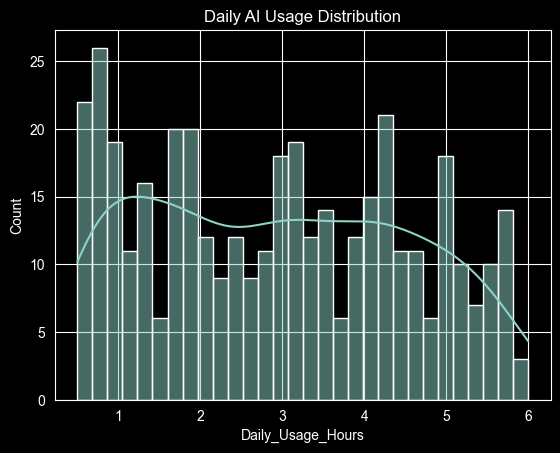

In [9]:
sns.histplot(df['Daily_Usage_Hours'], bins=30, kde=True)
plt.title('Daily AI Usage Distribution')
plt.show()

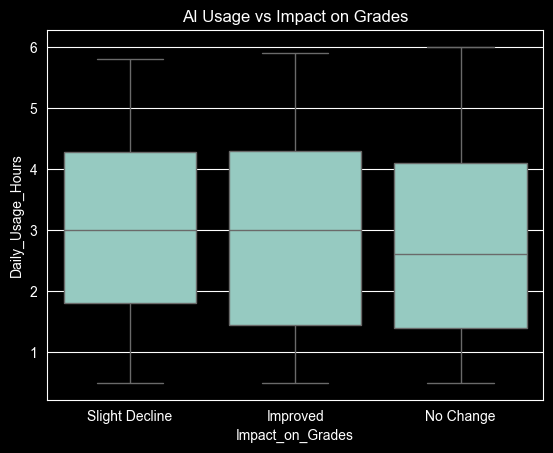

In [10]:
sns.boxplot(x='Impact_on_Grades', y='Daily_Usage_Hours', data=df)
plt.title('AI Usage vs Impact on Grades')
plt.show()

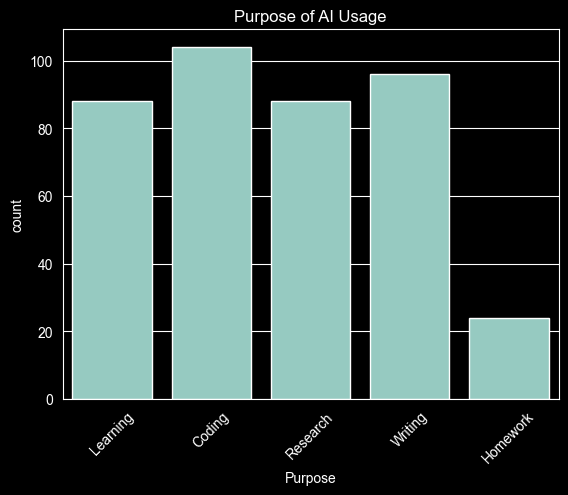

In [11]:
sns.countplot(x='Purpose', data=df)
plt.title('Purpose of AI Usage')
plt.xticks(rotation=45)
plt.show()

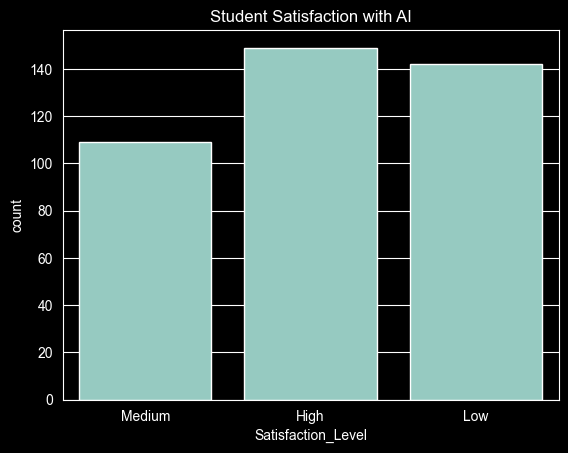

In [36]:
sns.countplot(x='Satisfaction_Level', data=df)
plt.title('Student Satisfaction with AI')
plt.show()

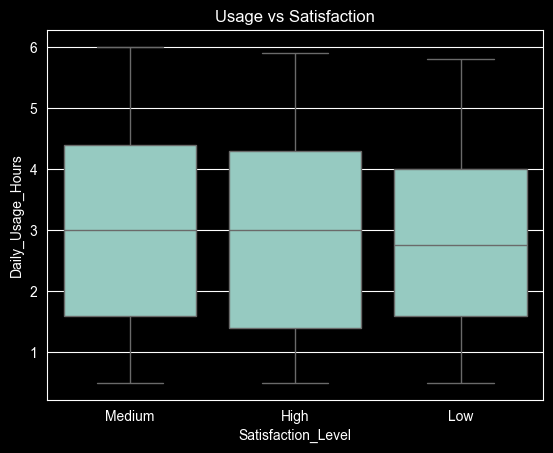

In [25]:
sns.boxplot(x='Satisfaction_Level', y='Daily_Usage_Hours', data=df)
plt.title('Usage vs Satisfaction')
plt.show()

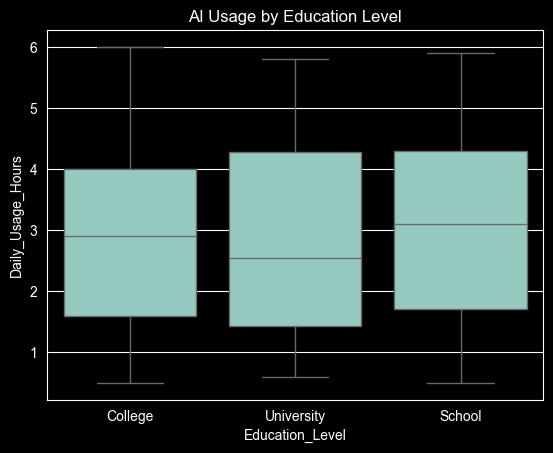

In [26]:
sns.boxplot(x='Education_Level', y='Daily_Usage_Hours', data=df)
plt.title('AI Usage by Education Level')
plt.show()

MACHINE LEARNING MODEL FOR AI USAGE

In [27]:
# Drop unnecessary columns
X = df.drop(['Impact_on_Grades', 'Student_ID'], axis=1)
y = df['Impact_on_Grades']

In [28]:
# Convert categorical variables into numeric
X = pd.get_dummies(X, drop_first=True)

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# Check mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Improved': np.int64(0), 'No Change': np.int64(1), 'Slight Decline': np.int64(2)}


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.3375
              precision    recall  f1-score   support

           0       0.26      0.39      0.31        23
           1       0.32      0.26      0.29        31
           2       0.50      0.38      0.43        26

    accuracy                           0.34        80
   macro avg       0.36      0.34      0.34        80
weighted avg       0.36      0.34      0.34        80



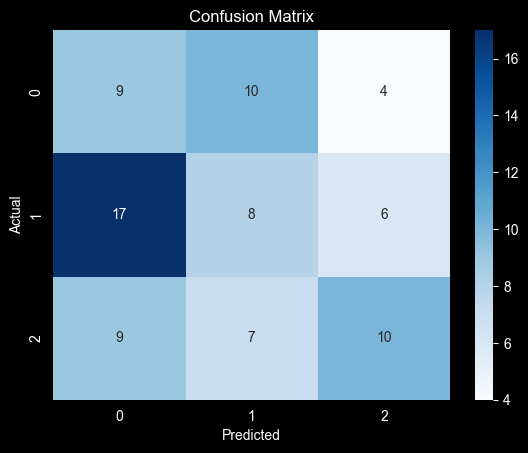

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [35]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

Daily_Usage_Hours             0.188809
Age                           0.152375
Gender_Male                   0.042700
AI_Tool_Used_Gemini           0.041903
Satisfaction_Level_Low        0.039850
Satisfaction_Level_Medium     0.038236
Education_Level_University    0.036991
Education_Level_School        0.036621
Purpose_Research              0.036241
Purpose_Writing               0.034705
dtype: float64

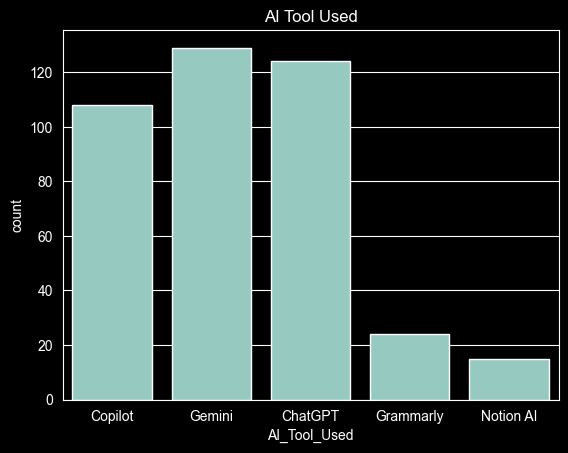

In [38]:
sns.countplot(x='AI_Tool_Used', data=df)
plt.title('AI Tool Used')
plt.show()

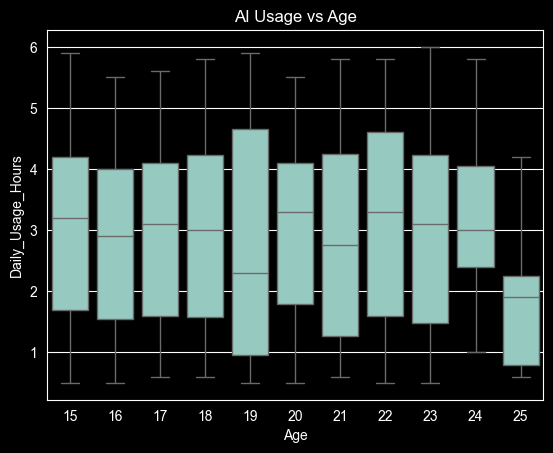

In [39]:
sns.boxplot(x='Age', y='Daily_Usage_Hours', data=df)
plt.title('AI Usage vs Age')
plt.show()

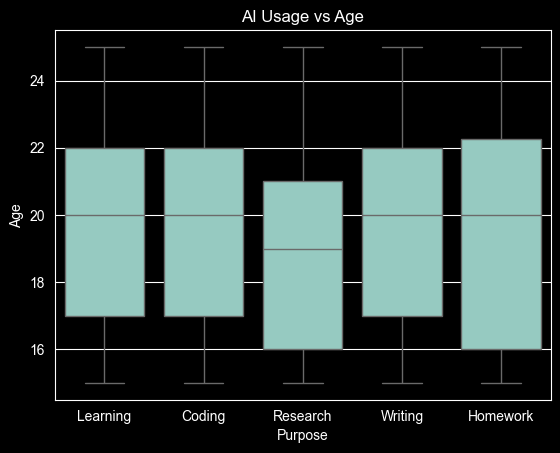

In [41]:
sns.boxplot(x='Purpose', y='Age', data=df)
plt.title('AI Usage vs Age')
plt.show()